## Q2. Using mid-point rule, trapezoid rules and Simpson 1/3 rule, show, compute the convergence rate, and compute with the actual values.




## ANS 

**Mid-point Rule**

$M_n = \sum_{i=1}^{n} f(m_i) \Delta x$.


**Trapezoid Rule**

$\int_a^b f(x) dx \approx \sum_{i=0}^{n-1} h \frac{f(x_i) + f(x_{i+1})}{2}$ $\\$

**Simpson 1/3 rule**

$$\int_{a}^{b} f(x) dx \approx \frac{(b-a)}{3} \bigg(f(a) + 4(\sum_{i=1, i \ odd}^{n-1} f(x_i)) + 2(\sum_{i=2,i \ even}^{n-2} f(x_i)) + f(b)\bigg)$$

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import sympy as sp

def Midpoint_rule(f,initial):
    [a,b,n] = initial
    x = np.linspace(a,b,n+1)
    #print(x)
    h = (b-a)/n
    sum = 0
    for i in range(len(x)-1):
        mi = (x[i]+x[i+1])/2
        #print(mi)
        sum = sum + f(mi) * h
    return sum

def Trapezoid_rule(f,initial):
    [a,b,n] = initial
    h = (b-a)/n
    
    x = np.linspace(a,b,n+1)
    #print(x)
    
    sum = 0
    for i in range(n):
        sum = sum + h * (f(x[i])+f(x[i+1]))/2
        #print(x[i])
    return sum

def Simpson_3rule(f,initial):
    [a,b,n] = initial
    
    S1 = f(a)
    
    S2 = 0
    h = (b-a)/n
    for i in range(1,n,2):
        x = a + i*h
        #print(f"S2 n = {i} x = {x}")
        S2 = S2 + f(x)
    S2 = 4 * S2

    S3 = 0
    for i in range(2,n-1,2):
        x = a + i*h
        #print(f"S3 n = {i} x = {x}")
        S3 = S3 + f(x)
    S3 = 2*S3

    S4 = f(b)
    
    #print(S1)
    #print(S4)

    return h/3*(S1 + S2 + S3 + S4)

def convergence_rate(f,initial, rule, exact_value, max_n=100):
    [a,b,_] = initial
    errors = []
    intervals = []
    for nc in range(2, max_n+1):
        approx = rule(f, [a,b,nc])
        error = abs(approx - exact_value)
        errors.append(error)
        intervals.append(nc)
    return intervals, errors

def plot_convergence(intervals, errors,label):
    plt.plot(intervals, errors, label=label)
    #plt.yscale('log')
    #plt.xscale('log')


### 1.$$ I_1 = \int_0^1 x^x \, dx \approx 0.783430510712 $$


In [32]:

f = lambda x: pow(x,x)

a ,b ,n = 0, 1, 1000000
initial = [a,b,n]

ans_midpoint = round( Midpoint_rule(f,initial),12)
ans_trapezoid = round( Trapezoid_rule(f,initial),12)
ans_simpson = round( Simpson_3rule(f,initial),12)

ans_quad = round(quad(f, a, b)[0],12)

print(f"True Value : {ans_quad}")

print(f"Midpoint rule : {ans_midpoint} ; with Truncation error : {abs(ans_midpoint - ans_quad)}")
print(f"Trapezoid rule : {ans_trapezoid} ; with Truncation error : {abs(ans_trapezoid - ans_quad)}")
print(f"Simpson 1/3 rule : {ans_simpson} ; with Truncation error : {abs(ans_simpson - ans_quad)}")


True Value : 0.783430510712
Midpoint rule : 0.783430510711 ; with Truncation error : 9.999778782798785e-13
Trapezoid rule : 0.783430510714 ; with Truncation error : 2.0000667788622195e-12
Simpson 1/3 rule : 0.783430510712 ; with Truncation error : 0.0


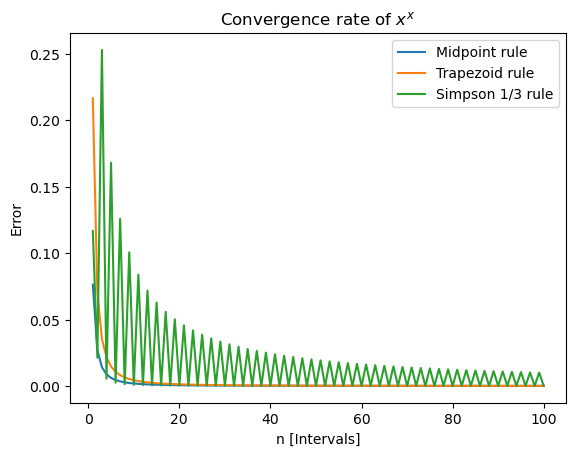

In [33]:

plt.figure()
x = sp.symbols('x')
f_expr = x ** x
f_latex = sp.latex(f_expr)

plt.title(f'Convergence rate of ${f_latex}$')

intervals, errors = convergence_rate(f,initial, Midpoint_rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Midpoint rule")

intervals, errors = convergence_rate(f,initial, Trapezoid_rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Trapezoid rule")

intervals, errors = convergence_rate(f,initial, Simpson_3rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Simpson 1/3 rule")

plt.xlabel('n [Intervals]')
plt.ylabel('Error')
plt.legend()
plt.show()



### 2.$$ I_2 = \int_0^1 \ln\left(\frac{1}{x}\right) \sin(x) \, dx \approx 0.239811742001 $$



In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


def Midpoint_rule(f,initial):
    [a,b,n] = initial
    x = np.linspace(a,b,n+1)
    #print(x)
    h = (b-a)/n
    sum = 0
    for i in range(len(x)-1):
        mi = (x[i]+x[i+1])/2
        #print(mi)
        try :
            sum = sum + f(mi) * h
        except:
            print(f"Error at {mi} but continuing")
    return sum

def Trapezoid_rule(f,initial):
    [a,b,n] = initial
    h = (b-a)/n

    # To handele the case when a = 0
    if a == 0:
        h = (b-a)/n
        a = h
        n = n-1
    
    x = np.linspace(a,b,n+1)
    #print(x)
    
    sum = 0
    for i in range(n):
        try :
            sum = sum + h * (f(x[i])+f(x[i+1]))/2
        except:
            print(f"Error at {x[i]} but continuing")
    
        #print(x[i])
    return sum

def Simpson_3rule(f,initial):
    [a,b,n] = initial

    # To handele the case when a = 0
    if a == 0:
        h = (b-a)/n
        a = h
        n = n-1

    
    try :
        S1 = f(a)
    except:
        print(f"Error at {b} but continuing")
    
    S2 = 0
    h = (b-a)/n
    for i in range(1,n,2):
        x = a + i*h
        #print(f"S2 n = {i} x = {x}")
        try :
            S2 = S2 + f(x)
        except:
            print(f"Error at {x} but continuing")
        
    S2 = 4 * S2

    S3 = 0
    for i in range(2,n-1,2):
        x = a + i*h
        #print(f"S3 n = {i} x = {x}")
        try :
            S3 = S3 + f(x)
        except:
            print(f"Error at {x} but continuing")
        
    S3 = 2*S3

   
    try :
        S4 = f(b)
    except:
        print(f"Error at {b} but continuing")
    
    
    #print(S1)
    #print(S4)

    return h/3*(S1 + S2 + S3 + S4)

In [57]:

f = lambda x: np.log(pow(x,-1))*np.sin(x)

a ,b ,n = 0, 1, 1000000
initial = [a,b,n]

ans_quad = round(quad(f, a, b)[0],12)
print(f"True Value : {ans_quad}")

ans_midpoint = round( Midpoint_rule(f,initial),12)
ans_trapezoid = round( Trapezoid_rule(f,initial),12)
ans_simpson = round( Simpson_3rule(f,initial),12)



print(f"Midpoint rule : {ans_midpoint} ; with Truncation error : {abs(ans_midpoint - ans_quad)}")
print(f"Trapezoid rule : {ans_trapezoid} ; with Truncation error : {abs(ans_trapezoid - ans_quad)}")
print(f"Simpson 1/3 rule : {ans_simpson} ; with Truncation error : {abs(ans_simpson - ans_quad)}")





True Value : 0.239811742001
Midpoint rule : 0.239811742001 ; with Truncation error : 0.0
Trapezoid rule : 0.239811741992 ; with Truncation error : 8.999995193548216e-12
Simpson 1/3 rule : 0.239811741993 ; with Truncation error : 7.999989559692722e-12


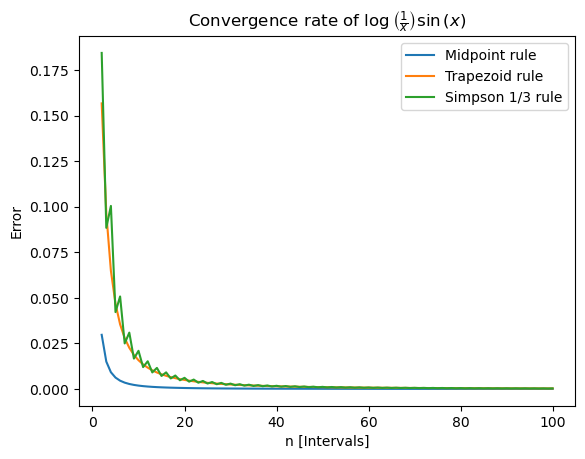

In [58]:
x = sp.symbols('x')
f_expr = sp.log(x**-1)*sp.sin(x)
f_latex = sp.latex(f_expr)

plt.title(f'Convergence rate of ${f_latex}$')

intervals, errors = convergence_rate(f,initial, Midpoint_rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Midpoint rule")

intervals, errors = convergence_rate(f,initial, Trapezoid_rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Trapezoid rule")

intervals, errors = convergence_rate(f,initial, Simpson_3rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Simpson 1/3 rule")


plt.xlabel('n [Intervals]')
plt.ylabel('Error')
plt.legend()
plt.show()


### 3. $$ I_3 = \int_0^1 x^5 e^{-2x} \, dx = \frac{1-3e^{-2}}{12} \approx 0.049499512524 $$


In [65]:

f = lambda x: pow(x,5)* pow(np.e,-2*pow(x,3))

a ,b ,n = 0, 1, 1000000
initial = [a,b,n]

ans_quad = round(quad(f, a, b)[0],12)
print(f"True Value : {ans_quad}")

print(f"True Value Anylatical : {round((1-3*np.e**-2)/12,12)}")


ans_midpoint = round( Midpoint_rule(f,initial),12)
ans_trapezoid = round( Trapezoid_rule(f,initial),12)
ans_simpson = round( Simpson_3rule(f,initial),12)



print(f"Midpoint rule : {ans_midpoint} ; with Truncation error : {abs(ans_midpoint - ans_quad)}")
print(f"Trapezoid rule : {ans_trapezoid} ; with Truncation error : {abs(ans_trapezoid - ans_quad)}")
print(f"Simpson 1/3 rule : {ans_simpson} ; with Truncation error : {abs(ans_simpson - ans_quad)}")

True Value : 0.049499512524
True Value Anylatical : 0.049499512524
Midpoint rule : 0.049499512524 ; with Truncation error : 0.0
Trapezoid rule : 0.049499512524 ; with Truncation error : 0.0
Simpson 1/3 rule : 0.049499377189 ; with Truncation error : 1.3533499999829335e-07


In [64]:
# solved using Sympy

x = sp.Symbol('x')
f_expr = x**5 * sp.exp(-2*x**3)

I3 = sp.integrate(f_expr, (x, 0, 1))
I3

1/12 - exp(-2)/4

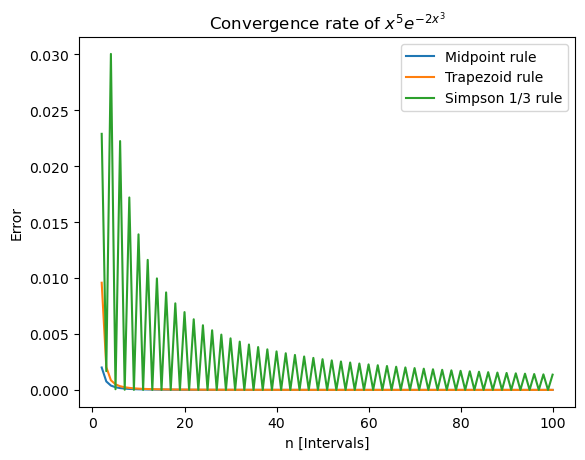

In [66]:
x = sp.symbols('x')
f_expr = x**5 * sp.exp(-2*x**3)
f_latex = sp.latex(f_expr)

plt.title(f'Convergence rate of ${f_latex}$')

intervals, errors = convergence_rate(f,initial, Midpoint_rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Midpoint rule")

intervals, errors = convergence_rate(f,initial, Trapezoid_rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Trapezoid rule")

intervals, errors = convergence_rate(f,initial, Simpson_3rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Simpson 1/3 rule")


plt.xlabel('n [Intervals]')
plt.ylabel('Error')
plt.legend()
plt.show()



### 4. $$ I_4 = \int_0^1 \left( x - \frac{x^3}{3!} + \frac{x^5}{5!} \right) dx = \frac{1}{2} - \frac{1}{4!} + \frac{1}{6!}  \approx 0.459722222222 $$ 

In [67]:
def fac(n):
    if n == 0:
        return 1
    else:
        return n * fac(n-1)

import sympy as sp
x = sp.symbols('x')
sp_f = x - x**3 / sp.factorial(3) + x**5 / sp.factorial(5)
I4 = sp.integrate(sp_f, (x, 0, 1))

print(I4)

f = lambda x: x-x**3/fac(3) + x**5/fac(5)

a ,b ,n = 0, 1, 1000000
initial = [a,b,n]

ans_quad = round(quad(f, a, b)[0],12)
print(f"True Value : {ans_quad}")

print(f"True Value Anylatical : {round(  1/2-1/fac(4)+1/fac(6) ,12)}")


ans_midpoint = round( Midpoint_rule(f,initial),12)
ans_trapezoid = round( Trapezoid_rule(f,initial),12)
ans_simpson = round( Simpson_3rule(f,initial),12)



print(f"Midpoint rule : {ans_midpoint} ; with Truncation error : {abs(ans_midpoint - ans_quad)}")
print(f"Trapezoid rule : {ans_trapezoid} ; with Truncation error : {abs(ans_trapezoid - ans_quad)}")
print(f"Simpson 1/3 rule : {ans_simpson} ; with Truncation error : {abs(ans_simpson - ans_quad)}")

331/720
True Value : 0.459722222222
True Value Anylatical : 0.459722222222
Midpoint rule : 0.459722222222 ; with Truncation error : 0.0
Trapezoid rule : 0.459722222222 ; with Truncation error : 0.0
Simpson 1/3 rule : 0.459721380556 ; with Truncation error : 8.41666000006569e-07


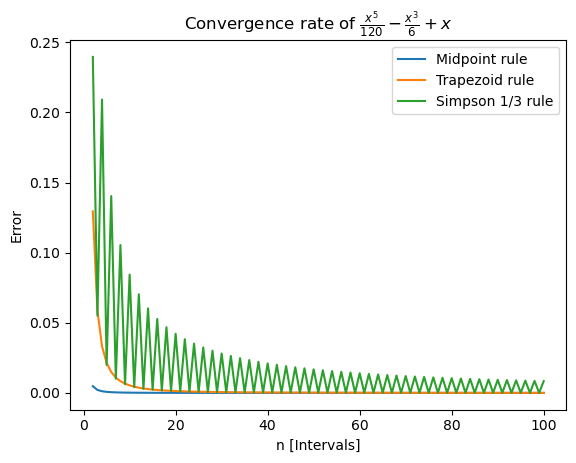

In [68]:
x = sp.symbols('x')
f_expr = x - x**3 / sp.factorial(3) + x**5 / sp.factorial(5)
f_latex = sp.latex(f_expr)

plt.title(f'Convergence rate of ${f_latex}$')

intervals, errors = convergence_rate(f,initial, Midpoint_rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Midpoint rule")

intervals, errors = convergence_rate(f,initial, Trapezoid_rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Trapezoid rule")

intervals, errors = convergence_rate(f,initial, Simpson_3rule, ans_quad, max_n=100)
plot_convergence(intervals, errors,"Simpson 1/3 rule")


plt.xlabel('n [Intervals]')
plt.ylabel('Error')
plt.legend()
plt.show()


## Q4. Evaluate the following using composite Simpson’s rule:





### 1. $$ I_1 = \int_0^1 x^x \, dx \approx 0.783430510712 $$



### 2. $$ I_2 = \int_0^{0.983} x^x dx \approx 0.766573383391 $$


### 3.  To see the inaccuracies of the abscissas ( $ a_j $ ), perform integration with (I) $ a_j = a_0 +jh $, and (II) $ a_j = a_{j-2} + 2h $ , and compare with the exact values.